# Матрично-векторное дифференцирование. Практика.

## Основная часть (всего 10 баллов)

__Задача 1. (1 балл)__ Для указанного графа вычислений найдите градиент $\nabla_A L, \nabla_b L$ функции потерь $L$ по входным переменным $A,b$ соответственно. Градиент по $x$ считать известным и равным $\nabla_x L$. Рекомендуется использовать алгоритм backpropogation.

_Замечание_: не обращайте внимание на размерность матрицы $A$, считайте, что она квадратная ($A \in \mathbb{R}^{n \times n}$)

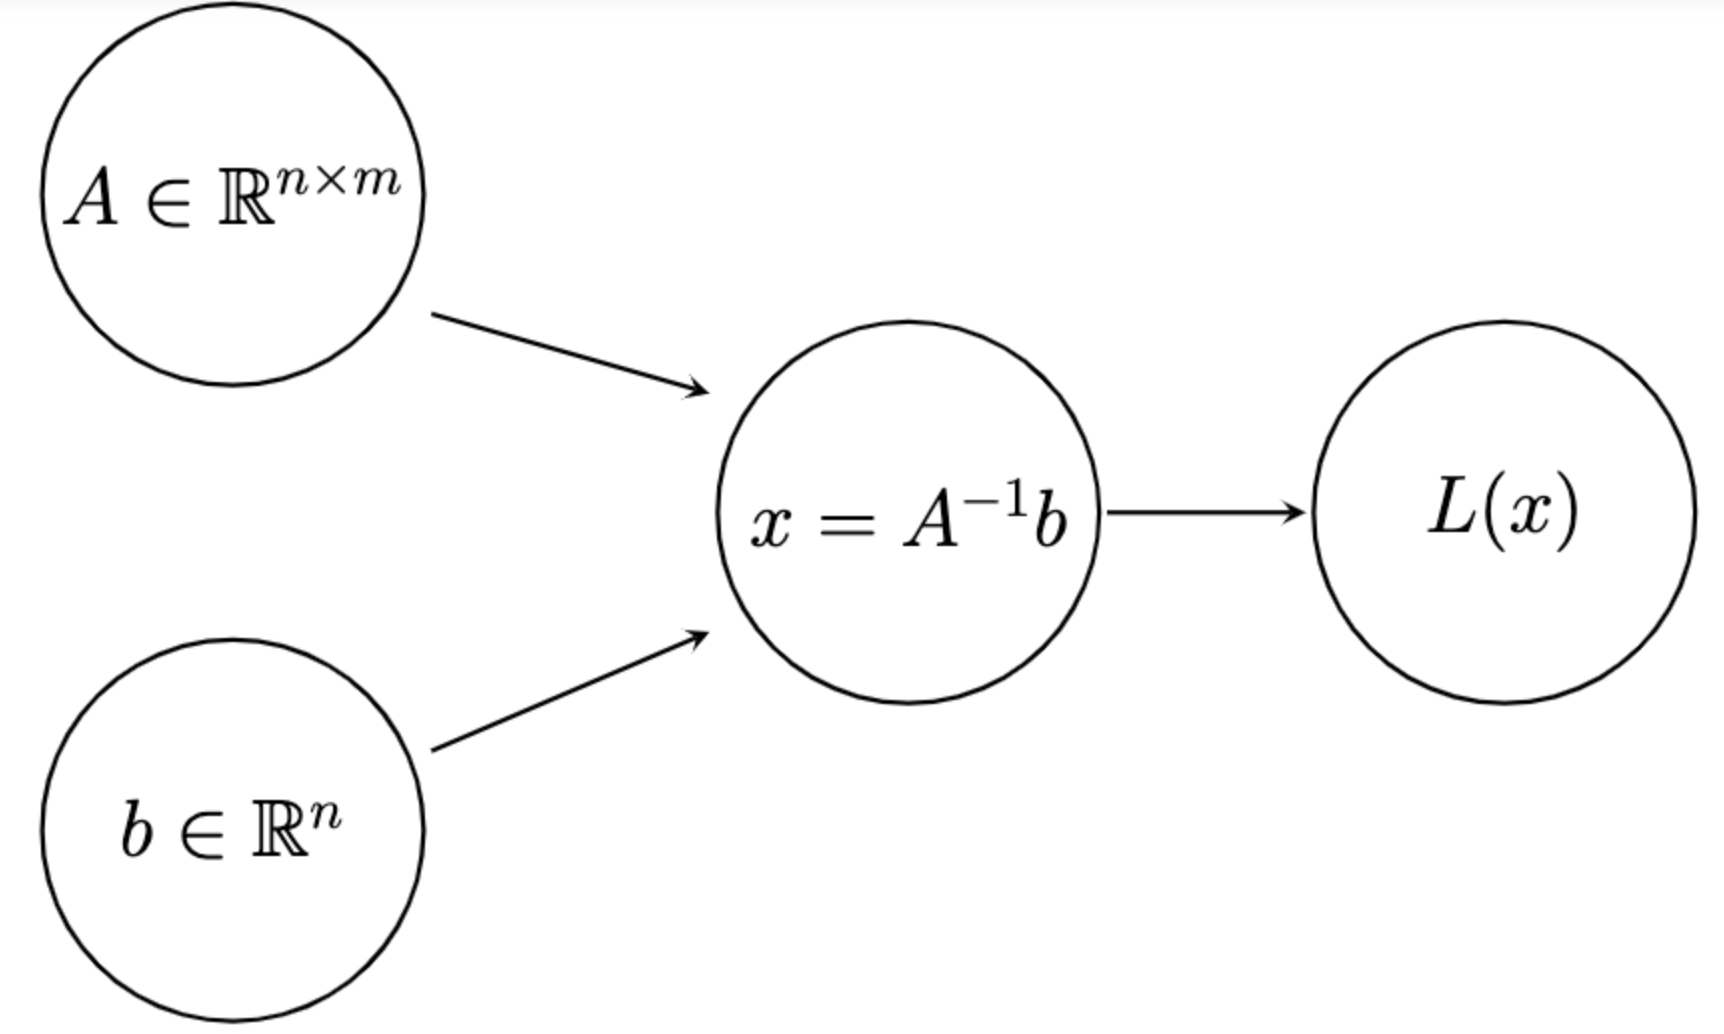

In [ ]:
# Ваше решение (Mardown)

Пусть $x = A^{-1} b$. Тогда
$x_i = \sum_{j=1}^n (A^{-1})_{ij} \, b_j. $

Чтобы найти $\frac{\partial L}{\partial b}$, используем правило цепочки:
$\frac{\partial L}{\partial b_j} = \sum_{i=1}^n \frac{\partial L}{\partial x_i} \,\frac{\partial x_i}{\partial b_j}. $

Но
$\frac{\partial x_i}{\partial b_j} = (A^{-1})_{ij}.$
Значит,
$\frac{\partial L}{\partial b_j} = \sum_{i=1}^n \nabla_x L \bigl[i\bigr]\,(A^{-1})_{ij}.$

В векторной форме это записывается как
$\nabla_b L = \bigl(A^{-1}\bigr)^T \,\nabla_x L. $
(Если считать $\nabla_x L$ столбцом, то результат $nabla_b L$ также будет столбцом.)

Итог:
$\nabla_b L = \bigl(A^{-1}\bigr)^T \,\nabla_x L. $


__Задача 2.__ Перед Вами стоит задача приближения матрицы $X  \in \mathbb{R}^{N \times M}$ неизвестными матрицами $U \in \mathbb{R}^{R\times N}, V \in \mathbb{R}^{R \times M}$ заданной размерности $R$. Такое приближение часто используется при поиске малоранговых приближений для передачи сжатой информации с минимальными потерями.

В качестве такого приближения предлагается использовать линейное представление $\hat{X} = U^T V$. Для оценки качества приближения будем использовать функцию *MSE*:
$$MSE(X, \hat{X}) = \frac{1}{2}||X - \hat{X} ||^2_F = \frac{1}{2}||X - U^T V||^2_F.$$

__a) (0.5 балла)__  Первым из предложенных методов будет обычный градиентный спуск. Для этого вычислите $\nabla_U MSE, \nabla_V MSE$ и реализуйте функцию ```grad(U, V, X)```, возвращающую значения для вычисленных аналитически градиентов.

In [ ]:
# Ваше решение (Mardown + Code)

Обозначим:
$E = U^\mathsf{T}V - X,$

тогда
$MSE(X, U^\mathsf{T}V) = \tfrac{1}{2} \|E\|_F^2. $

Рассмотрим компоненты $E_{i,j}$. Для $\nabla_U MSE$ удобно смотреть, как зависят элементы $E_{i,j}$ от элементов $U_{k,i}$. Нетрудно показать (либо через индексную запись, либо через тензорное/матричное дифференцирование), что:
$\nabla_U MSE = \frac{\partial}{\partial U} \Bigl(\tfrac{1}{2}\|E\|_F^2\Bigr) = V\,E^\mathsf{T},
$

$\nabla_V MSE = U\,E$

Здесь
$E=U^TV−X$(размерность N×M),U имеет размер R×N,V имеет размер R×M.


In [ ]:
def grad(U, V, X):
    '''
        U - матрица размера R*N;
        V - матрица размера R*M;
        X - матрица размера N*M.
    '''
    X_hat = U.T @ V  #  N x M
    E = X_hat - X    #  N x M

    grad_U = V @ E.T      #  (R x N)
    grad_V = U @ E        #  (R x M)
    # Ваше решение
    return grad_U, grad_V

В качестве матрицы $X$ предлагается рассмотреть изображение моста из датасета, созданного для бенчмаркинга различных матричных разложений *`ImageCompressionBenchmark'* (см. прикрепленный файл). Это делается для наглядности результатов, полученных при использовании оптимизационных методов.

In [ ]:
file_name = 'bridge.pgm'

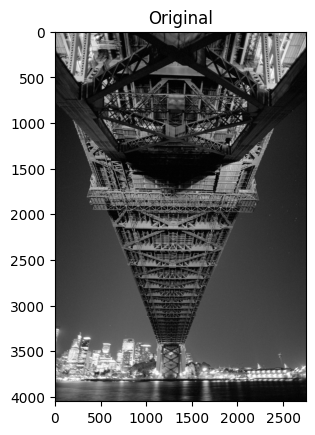

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

X = cv2.imread(file_name, -1)
plt.imshow(X, cmap='gray')
plt.title('Original')
plt.show()
N, M = X.shape

__б) (2 балла)__  Положим ранг $R = 10$. Реализуйте метод градиентного спуска, используя функцию подсчета градиента из предыдущего пункта. В качестве функции критерия используем *MSE*. Также необходимо сделать логгирование полученных значений критерии в зависимости от номера итерации $k$. Для удобства восприятия графиков ошибок, используйте отнормированные значения критерия, т.е.
$$\left(MSE (X, \hat{X}_k) ~/~ MSE (X, \hat{X}_0)\right),$$
где $ \hat{X}_k$ и $ \hat{X}_0$ - значения полученных аппроксимаций на $k$-ой и нулевой итерациях, соответсвенно.

Используйте предложенную функцию для реализации алгоритма и допишите недостающие фрагменты. После чего для проверки загрузите функцию в [контест](https://contest.yandex.ru/contest/66540/enter/).

In [ ]:
from tqdm import tqdm
def MatrixGD(grad, criterion, U_0, V_0, X, eps, max_iter, **params):

    '''
       grad(U, V, X) - функция, которая считает градиент целевой функции;
       criterion(X, X_k) - функция, которая считает критерий;
       U_0, V_0 - стартовые значения матриц U и V;
       X - матрица, приблежение которой ищем;
       eps - точность сходимости (обычно 1e-3);
       max_iter - количество итераций;
       **params - содержит именнованные гиперпараметры метода:
           params['gamma'](k) - шаг, зависящий от номера итерации;
    '''

    errors= []

    X_0= U_0.T @ V_0

    X_k= np.copy(X_0)
    U= np.copy(U_0)
    V= np.copy(V_0)

    err_x_0= criterion(X, X_k)
    errors.append(criterion(X, X_k) / err_x_0)

    for k in tqdm(range(max_iter)):

        # Ваше решение

        grad_U, grad_V= grad(U, V, X)


        gamma_k= params['gamma'](k)
        U= U - gamma_k * grad_U
        V= V - gamma_k * grad_V

        X_k = U.T @ V
        current_crit = criterion(X, X_k)

        errors.append(current_crit / err_x_0 if err_x_0 != 0 else 0.0)
        if errors[-1] < eps:
            break

    return X_k, errors

In [ ]:
def criterion(X, X_hat):
    diff= X - X_hat
    return 0.5 * np.sum(diff * diff)


__в) (1 балл)__ Запустите метод ```MatrixGD``` для сгенерированных стартовых матриц $U_0, V_0$ (функцию ```generate_starting_points``` изменять НЕ НУЖНО). В качестве шага подберите значение из предложенных: $\gamma = \{10^{-6}, 10^{-7}, 10^{-8}\}$.

Постройте график значений критерия от номера итерации. Выведите в виде картинки полученный результат.

In [ ]:
def generate_starting_points(R, N, M):
    np.random.seed(1)

    U = 0.01 * np.random.randn(R, N)
    V = 0.01 * np.random.randn(R, M)
    return U, V

  1%|          | 7/1000 [00:03<07:39,  2.16it/s]<ipython-input-12-27dd5ec91b35>:37: RuntimeWarning: overflow encountered in matmul
  X_k = U.T @ V
<ipython-input-12-27dd5ec91b35>:37: RuntimeWarning: invalid value encountered in matmul
  X_k = U.T @ V
  1%|          | 8/1000 [00:03<07:28,  2.21it/s]<ipython-input-9-8a3fdb3414bf>:7: RuntimeWarning: overflow encountered in matmul
  X_hat = U.T @ V  #  N x M
<ipython-input-9-8a3fdb3414bf>:7: RuntimeWarning: invalid value encountered in matmul
  X_hat = U.T @ V  #  N x M
100%|██████████| 1000/1000 [05:44<00:00,  2.90it/s]


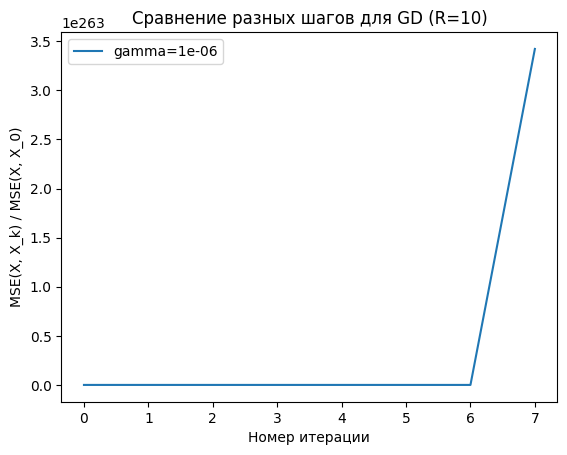

  1%|          | 11/1000 [00:04<06:34,  2.51it/s]<ipython-input-13-bf15b1a36309>:3: RuntimeWarning: overflow encountered in multiply
  return 0.5 * np.sum(diff * diff)
  1%|          | 12/1000 [00:04<06:30,  2.53it/s]<ipython-input-9-8a3fdb3414bf>:10: RuntimeWarning: overflow encountered in matmul
  grad_U = V @ E.T      #  (R x N)
<ipython-input-9-8a3fdb3414bf>:11: RuntimeWarning: overflow encountered in matmul
  grad_V = U @ E        #  (R x M)
100%|██████████| 1000/1000 [05:01<00:00,  3.32it/s]


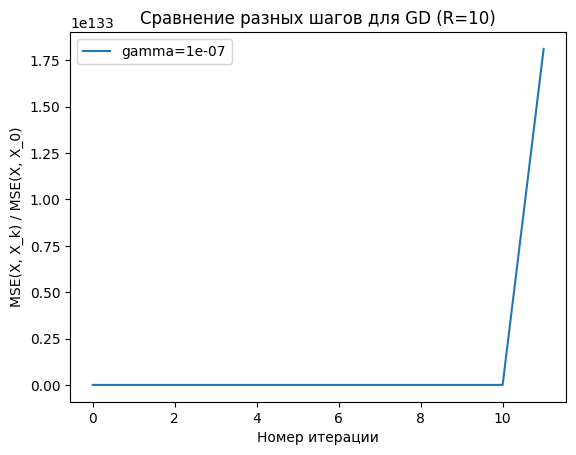

100%|██████████| 1000/1000 [05:29<00:00,  3.03it/s]


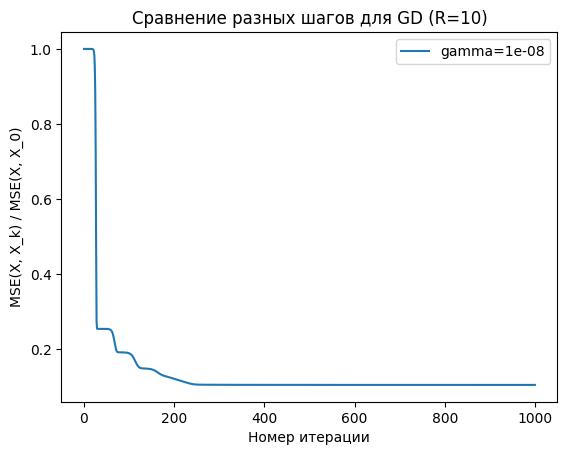

In [ ]:
# Ваше решение (Code)
gammas= [1e-6, 1e-7, 1e-8]
R= 10
U0, V0= generate_starting_points(R, N, M)
for gamma_val in gammas:
    def gamma_func(k):
        return gamma_val

    X_k, errors= MatrixGD(
        grad=grad,
        criterion=criterion,
        U_0=U0,
        V_0=V0,
        X=X,
        eps=1e-3,
        max_iter=1000,
        gamma=gamma_func
    )

    plt.plot(errors, label=f'gamma={gamma_val}')
    plt.xlabel('Номер итерации')
    plt.ylabel('MSE(X, X_k) / MSE(X, X_0)')
    plt.legend()
    plt.title('Сравнение разных шагов для GD (R=10)')
    plt.show()



__г) (1 балл)__ Следующий этап -- сравнить качество приближений в зависимости от ранга $R$. Рассмотрите следующие значения $R = \{1, 10, 100\}$. Постройте сравнительный график зависимости значения критерия от номера итерации $k$ и выведите в виде картинки полученный результат. Шаг оставьте тот, для которого наблюдалась сходимость в предыдущем пункте.

100%|██████████| 1000/1000 [09:31<00:00,  1.75it/s]


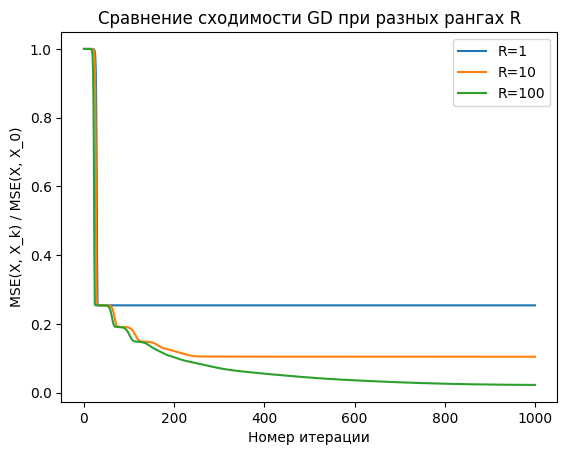

In [ ]:
# Ваше решение (Code)
Rs = [1, 10, 100]
gamma_val = 1e-8

for r in Rs:
    U0, V0 = generate_starting_points(r, N, M)

    def gamma_func(k):
        return gamma_val

    X_k, errors = MatrixGD(
        grad=grad,
        criterion=criterion,
        U_0=U0,
        V_0=V0,
        X=X,
        eps=1e-3,
        max_iter=1000,
        gamma=gamma_func
    )

    plt.plot(errors, label=f'R={r}')

plt.xlabel('Номер итерации')
plt.ylabel('MSE(X, X_k) / MSE(X, X_0)')
plt.legend()
plt.title('Сравнение сходимости GD при разных рангах R')
plt.show()


__Задача 3.__ Теперь, когда вы реализовали метод градиентного спуска для подсчета аппроксимации, перейдем к рассмотрению безградиентного метода AlternatingLeastSquares (ALS) также довольно популярного при работе с восстановлением изображений. На $k$-ой итерации выполняются следующие действия:
1. Для всех $i = 1, \ldots, N$ подсчитать обновленное значение $i$-го столбца матрицы $U_k$:
$$ \left[U_k\right]_i = \left( V_{k - 1} V_{k - 1}^T + \lambda I \right)^{-1} V_{k - 1} X_i^T $$
2. Для всех $j = 1, \ldots, M$ подсчитать обновленное значение $j$-го столбца матрицы $V_k$:
$$ \left[V_k\right]_j = \left( U_{k} U_{k}^T + \lambda I \right)^{-1} U_{k} X_j $$

__а) (2 балла)__ Реализуйте метод ALS c аналогичными требованиями, как и в MatrixGD.

Используйте предложенную функцию для реализации алгоритма и допишите недостающие фрагменты. После чего для проверки загрузите функцию в [контест](https://contest.yandex.ru/contest/66540/enter/).

In [ ]:
def ALS(criterion, U_0, V_0, X, eps, max_iter, **params):
    '''
        criterion(X, X_k) - функция, которая считает критерий;
        U_0, V_0 - стартовые значения матриц U и V;
        eps - точность сходимости (обычно 1e-3);
        X - матрица, приблежение которой ищем;
        max_iter - количество итераций;
        **params - содержит именнованные гиперпараметры метода:
            params['lmbda'] - константа для отрешивания задачи поиска обратной матрицы;
    '''

    errors= []
    lmbda= params['lmbda']  # Параметр регуляризации
    X_0= U_0.T @ V_0

    X_k= np.copy(X_0)
    U= np.copy(U_0)
    V= np.copy(V_0)

    err_x_0 = criterion(X, X_k)
    errors.append(criterion(X, X_k) / err_x_0)

    R = U_0.shape[0]

    for k in tqdm(range(max_iter)):

        # Ваше решение


        VVt = V @ V.T
        A_U = VVt + lmbda * np.eye(R)  # (R x R)

        for i in range(N):


            col_i= X[i, :]
            col_i= col_i.reshape(-1, 1)  # (M x 1)
            U[:, i] = np.linalg.solve(A_U, V @ col_i).ravel()


        UUt= U @ U.T
        A_V= UUt + lmbda * np.eye(R)

        for j in range(M):
            col_j= X[:, j].reshape(-1, 1)  # (N x 1)
            # V[:, j] (R x 1)
            # U (R x N), U @ col_j (R x 1)
            V[:, j] = np.linalg.solve(A_V, U @ col_j).ravel()


        X_k = U.T @ V
        current_crit = criterion(X, X_k)

        errors.append(criterion(X, X_k) / err_x_0)
        if errors[-1] < eps:
            break

    return X_k, errors

__б) (1 балл)__ Запустите метод ALS с максимальным числом итераций равным 100, рангом $R$ = 10 и значениями $\lambda = \{1, 10, 100\}$. Постройте сравнительный график значения критерия от номера итерации $k$. Восстановите изображения. Что можно сказать о параметре $\lambda$? Нужен ли он? Если да, то в каких случаях?

100%|██████████| 100/100 [00:57<00:00,  1.75it/s]


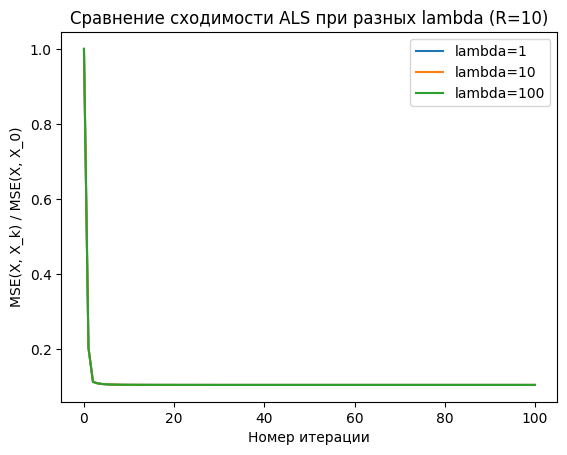

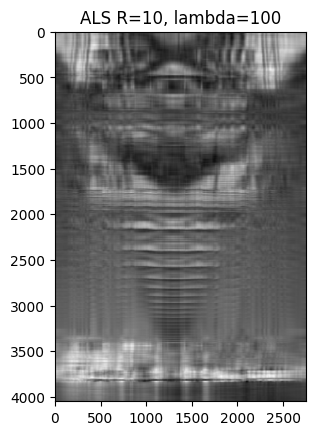

In [ ]:
# Ваше решение (Code + Markdown)
lambdas= [1, 10, 100]
R= 10
U0, V0= generate_starting_points(R, N, M)

for lmbd in lambdas:
    X_k, errors= ALS(
        criterion=criterion,
        U_0=U0,
        V_0=V0,
        X=X,
        eps=1e-3,
        max_iter=100,
        lmbda=lmbd
    )
    plt.plot(errors, label=f'lambda={lmbd}')

plt.xlabel('Номер итерации')
plt.ylabel('MSE(X, X_k) / MSE(X, X_0)')
plt.title('Сравнение сходимости ALS при разных lambda (R=10)')
plt.legend()
plt.show()

# Восстановим изображения и посмотрим
plt.imshow(X_k, cmap='gray')
plt.title(f'ALS R=10, lambda={lmbd}')
plt.show()


λиграет роль регуляризации (отрешивания) при вычислении $\bigl(V_{k-1} V_{k-1}^\mathsf{T} + \lambda I\bigr)^{-1} $и аналогично для $U_k U_k^\mathsf{T}.$ Если λ=0, могут возникнуть проблемы, когда матрица $V_{k-1}^\mathsf{T} $  (или $U_k U_k^\mathsf{T}$) оказывается вырожденной или плохо обусловленной (особенно при больших N, M и маленьком ранге R). Небольшое λ стабилизирует обращение, но слишком большое λ может "портить" решение, мешая достичь малой ошибки. То есть λ нужен, если мы хотим избежать вырождения при обратном вычислении и/или переобучения (при других постановках).

__в) (1 балл)__ Как и в предыдущем задании, теперь необходимо сравнить качество приближений в зависимости от ранга $R$. Число итераций поставьте равным 10. Рассмотрите следующие значения $R = \{1, 10, 100\}$. Постройте сравнительный график зависимости значения критерия от номера итерации $k$ и выведите в виде картинки полученный результат. Параметр $\lambda$ выберите на ваше усмотрение.

100%|██████████| 10/10 [00:31<00:00,  3.16s/it]


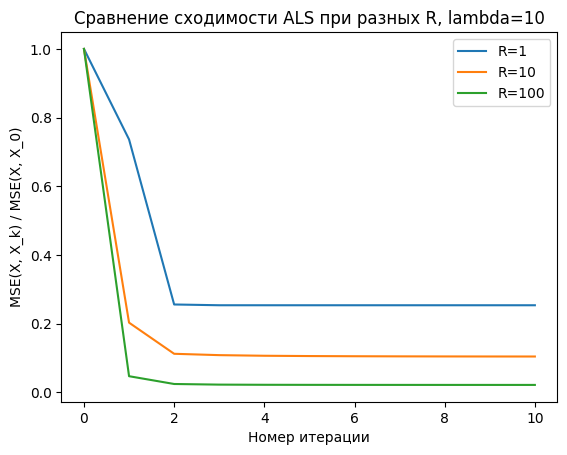

In [ ]:
# Ваше решение (Code)
Rs= [1, 10, 100]
lmbd= 10

for r in Rs:
    U0, V0= generate_starting_points(r, N, M)

    X_k, errors= ALS(
        criterion=criterion,
        U_0=U0,
        V_0=V0,
        X=X,
        eps=1e-3,
        max_iter=10,
        lmbda=lmbd
    )

    plt.plot(errors, label=f'R={r}')

plt.xlabel('Номер итерации')
plt.ylabel('MSE(X, X_k) / MSE(X, X_0)')
plt.title(f'Сравнение сходимости ALS при разных R, lambda={lmbd}')
plt.legend()
plt.show()


__г) (0.5 балла)__ Теперь, когда вы познакомились с двумя методами по поиску линейного разложения матрицы в случае фиксированного ранга, сделайте вывод о применимости каждого из них? Есть ли какие-то преимущества у метода ALS в сравнении с MatrixGD? Когда можно применять каждый из них?

In [ ]:
# Ваше решение (Code)


MatrixGD:

+:

Легко реализовать (простейший градиент).

Каждый шаг недорогой (просто обновление U, V по формуле).

-:


Может сходиться медленно, особенно при больших размерностях.

Требуется аккуратный подбор шага γ и возможные трюки с ускорением (momentum, адаптивные шаги и т.п.).

ALS:

+:

Является блочным координатным спуском: на каждом шаге мы решаем задачу "минимизации по U при фиксированном V" и наоборот.

Часто сходится быстрее (в смысле числа итераций) до неплохого решения, так как на каждом шаге «точно» решаем подзадачу по одной из матриц.

-:

Каждый шаг дороже вычислительно, так как нужно инвертировать матрицы $(V V^T + \lambda I)$ и $(U U^T + \lambda I)$ (размер R×R, что, впрочем, может быть не очень большим при небольшом ранге R).

Может быть чувствителен к тем же проблемам, если λ очень мало, а матрицы становятся вырожденными.


Обычно ALS применяют, когда ранг RR не очень велик, и тогда обращение (R×R)-матриц несложно и метод сходится за малое число итераций. Градиентный спуск может быть удобен, когда проще организовать поточный (online) или стохастический вариант (SGD), а также когда размеры очень велики и мы не можем позволить себе точное решение подсистем на каждом шаге.


## Реализация backpropagation

Этот часть относится к курсу Practical DL Школы анализа данных Яндекса.

## Дополнительная часть (всего 10 баллов)

__Задача 4.__ Как было рассказано на лекциях и семинарах, для поиска ошибки в машинном обучении строится граф вычислений на основе метода _backpropagation_. В данной части вам будет представлена возможность самостоятельно реализовать различные модули, используемые в нейронных сетях. Для начала представим универсальных класс ```Module```, который определит фундаментальные методы для обучения (в нем НЕ НУЖНО ничего менять).

Первым является __forward pass__ -- модуль получает входные данные, как-то их обрабатывает, а после выдает полученный результат, т.е.
$$\text{output = module.forward(input)}$$
Вторым же, как несложно догадаться, является __backward pass__ -- по цепному правилу (chain rule) прокидывается градиент от последнего слоя к первому, т.е.
$$\text{gradInput = module.backward(input, gradOutput)}$$

In [ ]:
class Module(object):
    def __init__ (self):
        self.output = None
        self.gradInput = None
        self.training = True

    def forward(self, input):
        return self.updateOutput(input)

    def backward(self,input, gradOutput):
        self.updateGradInput(input, gradOutput)
        self.accGradParameters(input, gradOutput)
        return self.gradInput


    def updateOutput(self, input):
        pass

    def updateGradInput(self, input, gradOutput):
        pass

    def accGradParameters(self, input, gradOutput):
        pass

    def zeroGradParameters(self):
        pass

    def getParameters(self):
        return []

    def getGradParameters(self):
        return []

    def train(self):
        self.training = True

    def evaluate(self):
        self.training = False

    def __repr__(self):
        return "Module"

__а) (2 балла)__ Реализуйте класс ```Sequential```, определяющий контейнер для последовательной обработки модулей (уровней).

In [ ]:
class Sequential(Module):
    def __init__ (self):
        super(Sequential, self).__init__()
        self.modules = []

    def add(self, module):
        self.modules.append(module)

    def updateOutput(self, input):
        '''
            В данной функции нужно реализовать
            последовательную передачу данных в
            forward pass, используя в качестве
            входа в новом уровне выход со старого.
        '''

        # Ваше решение
        self.output= input
        for module in self.modules:
            self.output= module.forward(self.output)
        return self.output

    def backward(self, input, gradOutput):
        '''
            Здесь нужно реализовать последовательную
            передачу градиента по цепному правилу.
            ВАЖНО: убедитесь в том, что при подсчете
            k-го градиента на вход подается output module[k-1],
            а не его input.

            g_k = module[k].backward(module[k - 1].output, g_{k + 1})
        '''

        # Ваше решение
        current_input= input
        outputs= [current_input]
        for module in self.modules:
            current_input= module.forward(current_input)
            outputs.append(current_input)


        grad= gradOutput
        for i in reversed(range(len(self.modules))):
            grad= self.modules[i].backward(outputs[i], grad)
        self.gradInput = grad
        return self.gradInput


    def zeroGradParameters(self):
        for module in self.modules:
            module.zeroGradParameters()

    def getParameters(self):
        return [x.getParameters() for x in self.modules]

    def getGradParameters(self):
        return [x.getGradParameters() for x in self.modules]

    def __repr__(self):
        string = "".join([str(x) + '\n' for x in self.modules])
        return string

    def __getitem__(self,x):
        return self.modules.__getitem__(x)

    def train(self):
        self.training = True
        for module in self.modules:
            module.train()

    def evaluate(self):
        self.training = False
        for module in self.modules:
            module.evaluate()

__б) (2 балла)__ Теперь реализуйте линейный слой (также известный как _dense layer, fully-connected layer, FC-layer_). Он работает с 2D входными даннами размера (n_samples, n_feature). Так как обычно данные передаются в виде батча, то вход и выход могут быть записаны так:
- input:   `batch_size x n_feature_1`
- output: `batch_size x n_feature_2`

In [ ]:
class Linear(Module):
    def __init__(self, n_in, n_out):
        super(Linear, self).__init__()

        stdv = 1./np.sqrt(n_in)
        self.W = np.random.uniform(-stdv, stdv, size = (n_out, n_in))
        self.b = np.random.uniform(-stdv, stdv, size = n_out)

        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)

    def updateOutput(self, input):
        # Ваше решение
        # self.output = ...
        self.output= input.dot(self.W.T) + self.b
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Ваше решение
        # self.gradInput = ...
        self.gradInput= gradOutput.dot(self.W)
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        # Ваше решение
        # self.gradW = ... ; self.gradb = ...
        self.gradW+= gradOutput.T.dot(input)
        self.gradb+= np.sum(gradOutput, axis=0)
        pass

    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

    def __repr__(self):
        s = self.W.shape
        q = 'Linear %d -> %d' %(s[1],s[0])
        return q

__в) (2 балла)__ Следующим будет нужно реализовать SoftMax слой, преобразующий полученные значения в аналог вероятности. Напомним, что функция softmax может быть определена следующим образом:
$$\text{softmax(x)}_i = \frac{\exp x_i}{\sum \limits_{j} \exp x_j}. $$

_Указание:_ чтобы избежать нестабильности в вычислении экспоненты от большого числа, используется следующее свойство:
$$\text{softmax(x)} = \text{softmax(x - const)}$$

In [ ]:
class SoftMax(Module):
    def __init__(self):
         super(SoftMax, self).__init__()

    def updateOutput(self, input):
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))

        # Ваше решение
        exp_x= np.exp(self.output)
        sum_exp= np.sum(exp_x, axis=1, keepdims=True)
        self.output= exp_x / sum_exp

        return self.output

    def updateGradInput(self, input, gradOutput):

        # Ваше решение
        s= self.output
        dot= np.sum(gradOutput * s, axis=1, keepdims=True)
        self.gradInput = s * (gradOutput - dot)
        return self.gradInput


    def __repr__(self):
        return "SoftMax"

__г) (2 балла)__ Ну и как же без функции активации, которая добавляет нелинейность в нейронную сеть. Рассмотрим самую популярную -- Leaky ReLU ([Leaky Rectified Linear Unit](https://en.wikipedia.org/wiki/Rectifier_(neural_networks)#Leaky_ReLUs)). Поэкспериментируйте со значением коэфциента наклона slope.

In [ ]:
class LeakyReLU(Module):
    def __init__(self, slope = 0.03):
        super(LeakyReLU, self).__init__()

        self.slope = slope

    def updateOutput(self, input):

        # Ваше решение
        self.output= np.where(input > 0, input, self.slope * input)
        return  self.output

    def updateGradInput(self, input, gradOutput):

        # Ваше решение
        self.gradInput= np.where(input > 0, gradOutput, self.slope * gradOutput)
        return self.gradInput

    def __repr__(self):
        return "LeakyReLU"

__д) (2 балла)__ Последний этап -- добавление критерия (функции потерь). Так как с MSE вы познакомились в основной части работы, то теперь к рассмотрению будет предложена ClassNLLCriterion. Он должен реализовывать [multiclass log loss](https://scikit-learn.org/stable/modules/model_evaluation.html#log-loss). Несмотря на то, что в этой формуле есть сумма по __y__ (target), помните, что target-ы кодируются с помощью one-hot encoder. Этот факт значительно упрощает вычисления. Обратите внимание, что критерии - единственное место, где вы делите на размер батча. Также есть небольшой хак с добавлением небольшого числа к вероятности, чтобы избежать вычисления log(0).
- input:   `batch_size x n_feats` - вероятности
- target: `batch_size x n_feats` - one-hot representation
- output: число

In [ ]:
class Criterion(object):
    def __init__ (self):
        self.output = None
        self.gradInput = None

    def forward(self, input, target):
        return self.updateOutput(input, target)

    def backward(self, input, target):
        return self.updateGradInput(input, target)

    def updateOutput(self, input, target):
        return self.output

    def updateGradInput(self, input, target):
        return self.gradInput

    def __repr__(self):
        return "Criterion"


class ClassNLLCriterion(Criterion):
    EPS = 1e-15
    def __init__(self):
        a = super(ClassNLLCriterion, self)
        super(ClassNLLCriterion, self).__init__()

    def updateOutput(self, input, target):

        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        # Ваше решение
        batch_size = input.shape[0]
        self.output = - np.sum(target * np.log(input_clamp)) / batch_size
        return self.output

    def updateGradInput(self, input, target):

        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        # Ваше решение
        batch_size= input.shape[0]
        self.gradInput= - (target / input_clamp) / batch_size
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterionUnstable"

### Тесты

Для вашего удобства проверки своих реализаций мы добавили автоматические тесты для каждого из реализованных классов.

In [ ]:
import torch
import numpy as np
import unittest
import sys

class TestLayers(unittest.TestCase):
    def test_Linear(self):
        np.random.seed(42)
        torch.manual_seed(42)

        batch_size, n_in, n_out = 2, 3, 4
        for _ in range(100):

            # Инициализация слоев
            torch_layer = torch.nn.Linear(n_in, n_out)
            custom_layer = Linear(n_in, n_out)
            custom_layer.W = torch_layer.weight.data.numpy()
            custom_layer.b = torch_layer.bias.data.numpy()

            layer_input = np.random.uniform(-10, 10, (batch_size, n_in)).astype(np.float32)
            next_layer_grad = np.random.uniform(-10, 10, (batch_size, n_out)).astype(np.float32)

            # 1. Проверка выхода слоя
            custom_layer_output = custom_layer.updateOutput(layer_input)
            layer_input_var = torch.from_numpy(layer_input).requires_grad_(True)
            torch_layer_output_var = torch_layer(layer_input_var)
            self.assertTrue(np.allclose(torch_layer_output_var.data.numpy(), custom_layer_output, atol=1e-6))

            # 2. Проверка градиента входа
            custom_layer_grad = custom_layer.updateGradInput(layer_input, next_layer_grad)
            torch_layer_output_var.backward(torch.from_numpy(next_layer_grad))
            torch_layer_grad_var = layer_input_var.grad
            self.assertTrue(np.allclose(torch_layer_grad_var.data.numpy(), custom_layer_grad, atol=1e-6))

            # 3. Проверка градиентов параметров
            custom_layer.accGradParameters(layer_input, next_layer_grad)
            weight_grad = custom_layer.gradW
            bias_grad = custom_layer.gradb
            torch_weight_grad = torch_layer.weight.grad.data.numpy()
            torch_bias_grad = torch_layer.bias.grad.data.numpy()
            self.assertTrue(np.allclose(torch_weight_grad, weight_grad, atol=1e-6))
            self.assertTrue(np.allclose(torch_bias_grad, bias_grad, atol=1e-6))

    def test_SoftMax(self):
        np.random.seed(42)
        torch.manual_seed(42)

        batch_size, n_in = 2, 4
        for _ in range(100):

            # Инициализация слоев
            torch_layer = torch.nn.Softmax(dim=1)
            custom_layer = SoftMax()

            layer_input = np.random.uniform(-10, 10, (batch_size, n_in)).astype(np.float32)
            next_layer_grad = np.random.random((batch_size, n_in)).astype(np.float32)
            next_layer_grad /= next_layer_grad.sum(axis=-1, keepdims=True)
            next_layer_grad = next_layer_grad.clip(1e-5,1.)
            next_layer_grad = 1. / next_layer_grad

            # 1. Проверка выхода слоя
            custom_layer_output = custom_layer.updateOutput(layer_input)
            layer_input_var = torch.from_numpy(layer_input).requires_grad_(True)
            torch_layer_output_var = torch_layer(layer_input_var)
            self.assertTrue(np.allclose(torch_layer_output_var.data.numpy(), custom_layer_output, atol=1e-5))

            # 2. Проверка градиента входа
            custom_layer_grad = custom_layer.updateGradInput(layer_input, next_layer_grad)
            torch_layer_output_var.backward(torch.from_numpy(next_layer_grad))
            torch_layer_grad_var = layer_input_var.grad
            self.assertTrue(np.allclose(torch_layer_grad_var.data.numpy(), custom_layer_grad, atol=1e-5))

    def test_LeakyReLU(self):
        np.random.seed(42)
        torch.manual_seed(42)

        batch_size, n_in = 2, 4
        for _ in range(100):

            # Инициализация слоев
            slope = np.random.uniform(0.01, 0.05)
            torch_layer = torch.nn.LeakyReLU(slope)
            custom_layer = LeakyReLU(slope)

            layer_input = np.random.uniform(-5, 5, (batch_size, n_in)).astype(np.float32)
            next_layer_grad = np.random.uniform(-5, 5, (batch_size, n_in)).astype(np.float32)

            # 1. Проверка выхода слоя
            custom_layer_output = custom_layer.updateOutput(layer_input)
            layer_input_var = torch.from_numpy(layer_input).requires_grad_(True)
            torch_layer_output_var = torch_layer(layer_input_var)
            self.assertTrue(np.allclose(torch_layer_output_var.data.numpy(), custom_layer_output, atol=1e-6))

            # 2. Проверка градиента входа
            custom_layer_grad = custom_layer.updateGradInput(layer_input, next_layer_grad)
            torch_layer_output_var.backward(torch.from_numpy(next_layer_grad))
            torch_layer_grad_var = layer_input_var.grad
            self.assertTrue(np.allclose(torch_layer_grad_var.data.numpy(), custom_layer_grad, atol=1e-6))

    def test_ClassNLLCriterion(self):
        np.random.seed(42)
        torch.manual_seed(42)

        batch_size, n_in = 2, 4
        for _ in range(100):

            # Инициализация слоев
            torch_layer = torch.nn.NLLLoss()
            custom_layer = ClassNLLCriterion()

            layer_input = np.random.uniform(0, 1, (batch_size, n_in)).astype(np.float32)
            layer_input /= layer_input.sum(axis=-1, keepdims=True)
            layer_input = layer_input.clip(custom_layer.EPS, 1. - custom_layer.EPS)
            target_labels = np.random.choice(n_in, batch_size)
            target = np.zeros((batch_size, n_in), np.float32)
            target[np.arange(batch_size), target_labels] = 1

            # 1. Проверка выхода слоя
            custom_layer_output = custom_layer.updateOutput(layer_input, target)
            layer_input_var = torch.from_numpy(layer_input).requires_grad_(True)

            torch_layer_output_var = torch_layer(
                torch.log(layer_input_var),
                torch.from_numpy(target_labels).to(torch.long))

            self.assertTrue(np.allclose(torch_layer_output_var.data.numpy(), custom_layer_output, atol=1e-6))

            # 2. Проверка градиента входа
            custom_layer_grad = custom_layer.updateGradInput(layer_input, target)
            torch_layer_output_var.backward()
            torch_layer_grad_var = layer_input_var.grad
            self.assertTrue(np.allclose(torch_layer_grad_var.data.numpy(), custom_layer_grad, atol=1e-6))

suite = unittest.TestLoader().loadTestsFromTestCase(TestLayers)
unittest.TextTestRunner(verbosity=2).run(suite)

test_ClassNLLCriterion (__main__.TestLayers.test_ClassNLLCriterion) ... ok
test_LeakyReLU (__main__.TestLayers.test_LeakyReLU) ... ok
test_Linear (__main__.TestLayers.test_Linear) ... ok
test_SoftMax (__main__.TestLayers.test_SoftMax) ... ok

----------------------------------------------------------------------
Ran 4 tests in 3.627s

OK


<unittest.runner.TextTestResult run=4 errors=0 failures=0>